# Feature Extraction Showcase

This notebook demonstrates the end-to-end feature engineering pipeline for speech pathology classification.

It covers:
- running extraction via `FeatureOptions`
- inspecting the generated multi-table outputs
- basic quality checks and quick exploratory plots

In [15]:
import sys
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append("..")

from src.features import FeatureOptions, load_feature_tables, summarize_feature_tables

In [16]:
# Configure extraction/loading behavior
opts = FeatureOptions(
    prefix=Path(".."),
    include_splits=True,
    random_seed=42,
    max_samples_per_class=200,  # Speed-up for testing; set None for full run.
    selected_token="a_n"
 )

opts

FeatureOptions(prefix=WindowsPath('..'), input_manifest=WindowsPath('data/processed/manifests/dataset_manifest.csv'), output_core=WindowsPath('data/processed/features/sample_core.csv'), output_acoustic=WindowsPath('data/processed/features/acoustic_features.csv'), output_multifractal=WindowsPath('data/processed/features/multifractal_features.csv'), output_opensmile=WindowsPath('data/processed/features/opensmile_features.csv'), output_splits=WindowsPath('data/processed/features/sample_splits.csv'), output_summary_json=WindowsPath('data/processed/features/feature_summary.json'), include_splits=True, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_seed=42, max_samples_per_class=200, normalize_audio=True, target_sample_rate=None, selected_token='a_n', mfdfa_order=1, mfdfa_q_min=-5.0, mfdfa_q_max=5.0, mfdfa_q_step=1.0, mfdfa_num_scales=20)

In [17]:
# Build missing tables if needed, otherwise load cached outputs
tables = load_feature_tables(options=opts, build_if_missing=True, save_if_built=True)
summary = summarize_feature_tables(tables)
summary

{'num_samples': 595,
 'num_acoustic_rows': 595,
 'num_multifractal_rows': 595,
 'num_opensmile_rows': 595,
 'feature_status_counts': {'ok': 595},
 'acoustic_status_counts': {'ok': 595},
 'multifractal_status_counts': {'ok': 595},
 'opensmile_status_counts': {'ok': 595},
 'split_counts': {'train': 445, 'test': 76, 'val': 74}}

## Inspect generated tables

The pipeline creates separate tables for metadata/core status, acoustic features, multifractal features, and splits.

In [18]:
for name, df in tables.items():
    print(f"{name}: shape={df.shape}")

core_df = tables["core"]
acoustic_df = tables["acoustic"]
multifractal_df = tables["multifractal"]
opensmile_df = tables["opensmile"]
splits_df = tables.get("splits", pd.DataFrame())

core: shape=(595, 18)
acoustic: shape=(595, 87)
multifractal: shape=(595, 17)
opensmile: shape=(595, 91)
splits: shape=(595, 3)


In [19]:
core_df.head()

,sample_key,duplicate_class_key,recording_id,speaker_id,pathology_de,pathology_en,is_healthy,modality,token,sex,is_overlap_speaker,is_overlap_speaker_id,wav_path,feature_status,feature_error,audio_sample_rate,audio_num_samples,audio_duration_seconds
0,Morbus Parkinson::1580::vowels::a_n,Morbus Parkinson::1580,1580,1887,Morbus Parkinson,parkinson's disease,False,vowels,a_n,m,False,False,..\data\processed\wav\Morbus Parkinson\1580\vo...,ok,NaN,50000,36123,0.72246
1,Phonationsknötchen::131::vowels::a_n,Phonationsknötchen::131,131,1317,Phonationsknötchen,Phonationsknötchen,False,vowels,a_n,m,True,True,..\data\processed\wav\Phonationsknötchen\131\...,ok,NaN,50000,99699,1.99398
2,Phonationsknötchen::870::vowels::a_n,Phonationsknötchen::870,870,1466,Phonationsknötchen,Phonationsknötchen,False,vowels,a_n,w,False,False,..\data\processed\wav\Phonationsknötchen\870\...,ok,NaN,50000,26518,0.53036
3,Phonationsknötchen::900::vowels::a_n,Phonationsknötchen::900,900,1492,Phonationsknötchen,Phonationsknötchen,False,vowels,a_n,m,False,False,..\data\processed\wav\Phonationsknötchen\900\...,ok,NaN,50000,68918,1.37836
4,Phonationsknötchen::1044::vowels::a_n,Phonationsknötchen::1044,1044,1540,Phonationsknötchen,Phonationsknötchen,False,vowels,a_n,w,False,False,..\data\processed\wav\Phonationsknötchen\1044...,ok,NaN,50000,58868,1.17736


In [20]:
acoustic_df.head()

,sample_key,acoustic_status,acoustic_error,ac_time_energy,ac_time_abs_mean,ac_time_peak,ac_time_crest_factor,ac_rms_mean,ac_rms_std,ac_rms_min,...,ac_mfcc12_delta_mean,ac_mfcc12_delta_std,ac_mfcc13_mean,ac_mfcc13_std,ac_mfcc13_delta_mean,ac_mfcc13_delta_std,ac_f0_mean,ac_f0_std,ac_f0_min,ac_f0_max
0,Morbus Parkinson::1580::vowels::a_n,ok,NaN,0.110912,0.268923,1.0,3.002687,0.329604,0.023253,0.230419,...,0.030101,0.584257,-5.779543,4.559168,-0.134036,0.645118,160.845648,2.690300,152.663472,165.905134
1,Phonationsknötchen::131::vowels::a_n,ok,NaN,0.064004,0.190209,1.0,3.952712,0.247352,0.049943,0.163825,...,0.062483,0.625103,0.142729,3.620284,0.031361,0.649691,127.424556,2.014915,123.033541,132.339913
2,Phonationsknötchen::870::vowels::a_n,ok,NaN,0.144138,0.308224,1.0,2.633973,0.374744,0.026643,0.293857,...,0.090107,0.503915,-7.921098,2.676857,-0.045758,0.342567,242.015959,1.179138,240.182842,243.624202
3,Phonationsknötchen::900::vowels::a_n,ok,NaN,0.075708,0.232203,1.0,3.634367,0.269972,0.045038,0.190363,...,-0.027003,0.657946,3.491962,4.574242,0.030746,0.608782,238.931114,0.856195,236.869269,240.942065
4,Phonationsknötchen::1044::vowels::a_n,ok,NaN,0.152977,0.317708,1.0,2.556744,0.388792,0.017180,0.297022,...,0.033218,0.504071,-13.612607,3.798492,-0.065852,0.334661,227.768198,0.820300,226.508584,229.696225


In [21]:
multifractal_df.head()

,sample_key,mf_status,mf_error,mf_hq_mean,mf_hq_std,mf_hq_min,mf_hq_max,mf_tau_mean,mf_tau_std,mf_alpha_mean,mf_alpha_std,mf_spectrum_width,mf_spectrum_peak_alpha,mf_spectrum_peak_f,mf_spectrum_asymmetry,mf_num_scales,mf_num_q
0,Morbus Parkinson::1580::vowels::a_n,ok,NaN,0.754653,0.169290,0.559381,1.035577,-1.550596,2.617846,0.814805,0.292166,0.752851,0.629105,0.973514,0.224294,20,10
1,Phonationsknötchen::131::vowels::a_n,ok,NaN,0.620243,0.200857,0.368035,0.922110,-1.661350,2.154483,0.655044,0.328177,0.823096,0.468828,0.942194,0.294731,20,10
2,Phonationsknötchen::870::vowels::a_n,ok,NaN,0.410781,0.144249,0.238638,0.643916,-1.471740,1.463533,0.453548,0.246218,0.627353,0.304024,0.970301,0.250701,20,10
3,Phonationsknötchen::900::vowels::a_n,ok,NaN,0.456957,0.106623,0.324965,0.630235,-1.350005,1.575347,0.486127,0.188018,0.498964,0.379990,0.977592,0.290839,20,10
4,Phonationsknötchen::1044::vowels::a_n,ok,NaN,0.617934,0.115869,0.477110,0.799486,-1.380524,2.104084,0.646773,0.193525,0.488622,0.530861,0.970529,0.243153,20,10


In [22]:
opensmile_df.head()

,sample_key,opensmile_status,opensmile_error,os_F0semitoneFrom27.5Hz_sma3nz_amean,os_F0semitoneFrom27.5Hz_sma3nz_stddevNorm,os_F0semitoneFrom27.5Hz_sma3nz_percentile20.0,os_F0semitoneFrom27.5Hz_sma3nz_percentile50.0,os_F0semitoneFrom27.5Hz_sma3nz_percentile80.0,os_F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,os_F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,...,os_slopeUV0-500_sma3nz_amean,os_slopeUV500-1500_sma3nz_amean,os_spectralFluxUV_sma3nz_amean,os_loudnessPeaksPerSec,os_VoicedSegmentsPerSec,os_MeanVoicedSegmentLengthSec,os_StddevVoicedSegmentLengthSec,os_MeanUnvoicedSegmentLength,os_StddevUnvoicedSegmentLength,os_equivalentSoundLevel_dBp
0,Morbus Parkinson::1580::vowels::a_n,ok,NaN,30.619734,0.007817,30.419205,30.542192,30.879210,0.460005,6.967229,...,0.0,0.0,0.0,2.816901,1.538462,0.64,0.0,0.0,0.0,-15.389905
1,Phonationsknötchen::131::vowels::a_n,ok,NaN,26.547932,0.010170,26.302229,26.543545,26.769644,0.467415,4.163887,...,0.0,0.0,0.0,3.535354,0.520833,1.91,0.0,0.0,0.0,-14.512176
2,Phonationsknötchen::870::vowels::a_n,ok,NaN,37.668079,0.002291,37.577351,37.649559,37.761257,0.183907,1.243973,...,0.0,0.0,0.0,3.846154,2.173913,0.45,0.0,0.0,0.0,-8.524747
3,Phonationsknötchen::900::vowels::a_n,ok,NaN,37.434544,0.001597,37.384712,37.429161,37.488220,0.103508,0.989623,...,0.0,0.0,0.0,5.147059,0.769231,1.29,0.0,0.0,0.0,-14.684231
4,Phonationsknötchen::1044::vowels::a_n,ok,NaN,36.599426,0.001533,36.546352,36.591766,36.639912,0.093559,1.062952,...,0.0,0.0,0.0,6.034483,0.909091,1.09,0.0,0.0,0.0,-15.348408


## Join features for modeling

Join on `sample_key` to obtain one model-ready view while preserving separate storage tables.

In [23]:
model_df = core_df.merge(acoustic_df, on="sample_key", how="left")
model_df = model_df.merge(multifractal_df, on="sample_key", how="left")
model_df = model_df.merge(opensmile_df, on="sample_key", how="left")

if not splits_df.empty:
    model_df = model_df.merge(splits_df, on="sample_key", how="left")

model_df.head()

,sample_key,duplicate_class_key,recording_id,speaker_id,pathology_de,pathology_en,is_healthy,modality,token,sex,...,os_spectralFluxUV_sma3nz_amean,os_loudnessPeaksPerSec,os_VoicedSegmentsPerSec,os_MeanVoicedSegmentLengthSec,os_StddevVoicedSegmentLengthSec,os_MeanUnvoicedSegmentLength,os_StddevUnvoicedSegmentLength,os_equivalentSoundLevel_dBp,split,split_seed
0,Morbus Parkinson::1580::vowels::a_n,Morbus Parkinson::1580,1580,1887,Morbus Parkinson,parkinson's disease,False,vowels,a_n,m,...,0.0,2.816901,1.538462,0.64,0.0,0.0,0.0,-15.389905,train,42
1,Phonationsknötchen::131::vowels::a_n,Phonationsknötchen::131,131,1317,Phonationsknötchen,Phonationsknötchen,False,vowels,a_n,m,...,0.0,3.535354,0.520833,1.91,0.0,0.0,0.0,-14.512176,val,42
2,Phonationsknötchen::870::vowels::a_n,Phonationsknötchen::870,870,1466,Phonationsknötchen,Phonationsknötchen,False,vowels,a_n,w,...,0.0,3.846154,2.173913,0.45,0.0,0.0,0.0,-8.524747,train,42
3,Phonationsknötchen::900::vowels::a_n,Phonationsknötchen::900,900,1492,Phonationsknötchen,Phonationsknötchen,False,vowels,a_n,m,...,0.0,5.147059,0.769231,1.29,0.0,0.0,0.0,-14.684231,test,42
4,Phonationsknötchen::1044::vowels::a_n,Phonationsknötchen::1044,1044,1540,Phonationsknötchen,Phonationsknötchen,False,vowels,a_n,w,...,0.0,6.034483,0.909091,1.09,0.0,0.0,0.0,-15.348408,train,42


In [24]:
print(f"{core_df.columns=}")
print(f"{acoustic_df.columns=}")
print(f"{multifractal_df.columns=}")
print(f"{opensmile_df.columns=}")

core_df.columns=Index(['sample_key', 'duplicate_class_key', 'recording_id', 'speaker_id',
       'pathology_de', 'pathology_en', 'is_healthy', 'modality', 'token',
       'sex', 'is_overlap_speaker', 'is_overlap_speaker_id', 'wav_path',
       'feature_status', 'feature_error', 'audio_sample_rate',
       'audio_num_samples', 'audio_duration_seconds'],
      dtype='str')
acoustic_df.columns=Index(['sample_key', 'acoustic_status', 'acoustic_error', 'ac_time_energy',
       'ac_time_abs_mean', 'ac_time_peak', 'ac_time_crest_factor',
       'ac_rms_mean', 'ac_rms_std', 'ac_rms_min', 'ac_rms_max', 'ac_zcr_mean',
       'ac_zcr_std', 'ac_zcr_min', 'ac_zcr_max', 'ac_spec_centroid_mean',
       'ac_spec_centroid_std', 'ac_spec_centroid_min', 'ac_spec_centroid_max',
       'ac_spec_bandwidth_mean', 'ac_spec_bandwidth_std',
       'ac_spec_bandwidth_min', 'ac_spec_bandwidth_max',
       'ac_spec_rolloff_mean', 'ac_spec_rolloff_std', 'ac_spec_rolloff_min',
       'ac_spec_rolloff_max', 'ac_spec_

In [25]:
# Basic quality checks
status_cols = [c for c in ["feature_status", "acoustic_status", "mf_status"] if c in model_df.columns]
for col in status_cols:
    print(f"\n{col}\n", model_df[col].value_counts(dropna=False))

print("\nMissingness (top 20 columns):")
display(model_df.isna().mean().sort_values(ascending=False).head(20))


feature_status
 feature_status
ok    595
Name: count, dtype: int64

acoustic_status
 acoustic_status
ok    595
Name: count, dtype: int64

mf_status
 mf_status
ok    595
Name: count, dtype: int64

Missingness (top 20 columns):


feature_error            1.0
acoustic_error           1.0
opensmile_error          1.0
mf_error                 1.0
speaker_id               0.0
recording_id             0.0
pathology_de             0.0
pathology_en             0.0
token                    0.0
sex                      0.0
is_healthy               0.0
modality                 0.0
is_overlap_speaker_id    0.0
is_overlap_speaker       0.0
feature_status           0.0
wav_path                 0.0
audio_sample_rate        0.0
audio_num_samples        0.0
sample_key               0.0
duplicate_class_key      0.0
dtype: float64

## Quick exploratory plots

These are lightweight sanity checks to visualize class balance and a few extracted features.

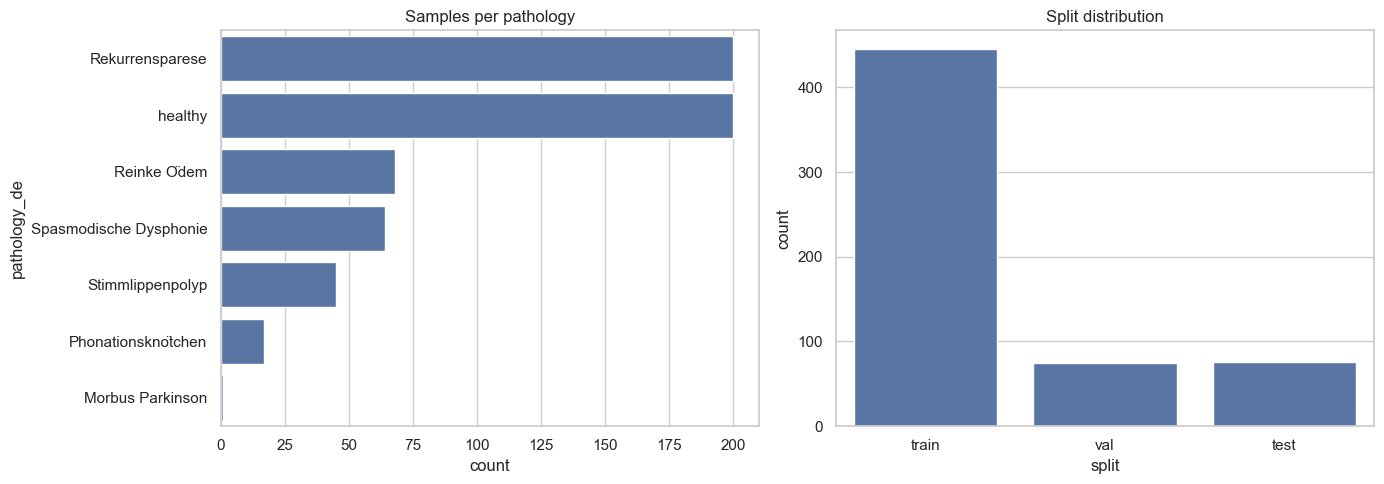

In [26]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

if "pathology_de" in model_df.columns:
    order = model_df["pathology_de"].value_counts().index
    sns.countplot(data=model_df, y="pathology_de", order=order, ax=ax[0])
    ax[0].set_title("Samples per pathology")

if "split" in model_df.columns:
    sns.countplot(data=model_df, x="split", order=["train", "val", "test"], ax=ax[1])
    ax[1].set_title("Split distribution")
else:
    ax[1].axis("off")

plt.tight_layout()
plt.show()

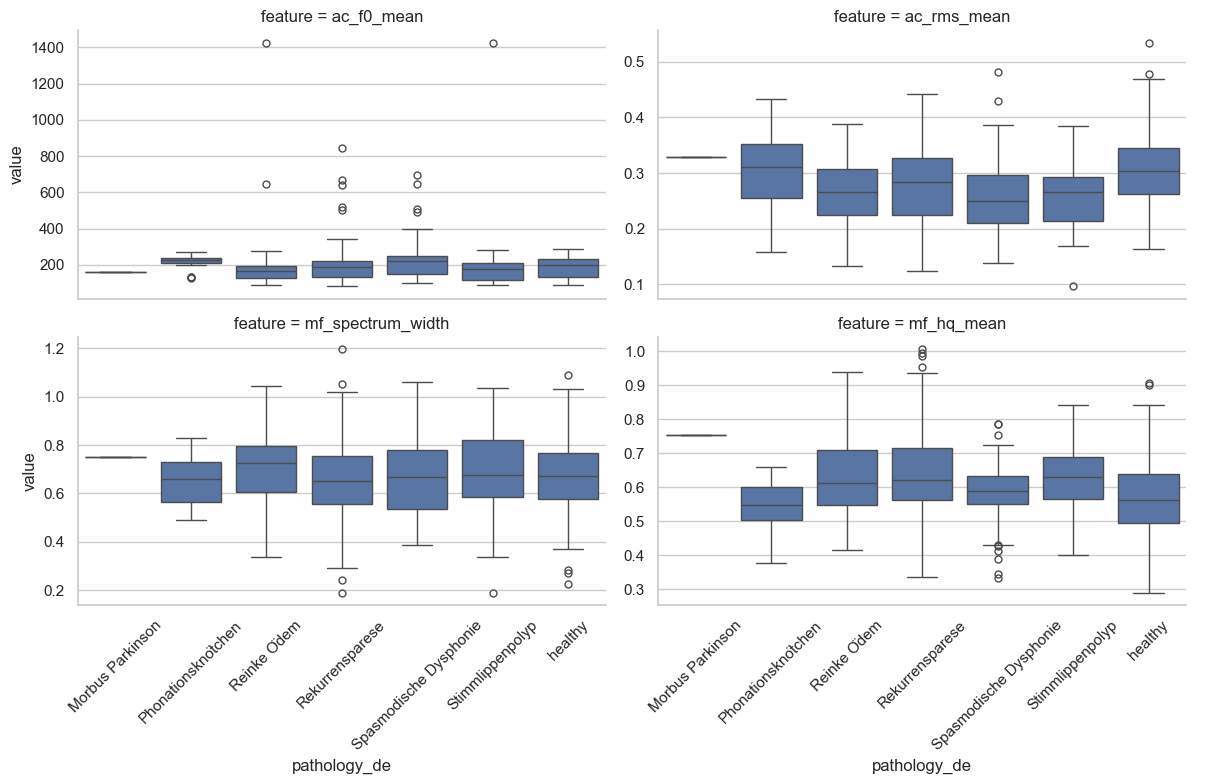

In [27]:
candidate_features = ["ac_f0_mean", "ac_rms_mean", "mf_spectrum_width", "mf_hq_mean"]
existing = [c for c in candidate_features if c in model_df.columns]

if existing and "pathology_de" in model_df.columns:
    plot_df = model_df[["pathology_de", *existing]].copy()
    melted = plot_df.melt(id_vars="pathology_de", var_name="feature", value_name="value")

    g = sns.catplot(
        data=melted,
        x="pathology_de",
        y="value",
        col="feature",
        col_wrap=2,
        kind="box",
        sharey=False,
        height=4,
        aspect=1.5,
    )
    for axis in g.axes.flatten():
        axis.tick_params(axis="x", rotation=45)
    g.fig.tight_layout()
    plt.show()
else:
    print("No candidate columns found yet for feature-by-pathology plot.")

## Persist a model-ready snapshot (optional)

Use this cell if you want a single joined table for rapid prototyping.

In [28]:
out_path = Path("..") / "data" / "processed" / "features" / "model_table_snapshot.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
model_df.to_csv(out_path, index=False)
print(f"Wrote: {out_path.resolve()}")

Wrote: G:\Projects\multifractal-speech-analysis\data\processed\features\model_table_snapshot.csv
